In [ ]:
import pandas as pd

df = pd.read_excel("ecommerce_sales_data (2).xlsx")

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

In [ ]:
df = pd.read_excel("/content/ecommerce_sales_data (2).xlsx")

print("=" * 50)
print("7 DÒNG ĐẦU TIÊN")
print(df.head(7))

print("=" * 50)
print("5 DÒNG CUỐI CÙNG")
print(df.tail(5))

print("=" * 50)
print("THÔNG TIN TỔNG QUAN")
print(df.info())

print("=" * 50)
print("THỐNG KÊ MÔ TẢ")
print(df.describe())


7 DÒNG ĐẦU TIÊN
   OrderID        Date CustomerID Product_Category            Product_Name  \
0  ORD0001  2025-11-24    CUST027         Clothing                   Jeans   
1  ORD0002  2025-02-27    CUST025      Electronics              Smartphone   
2  ORD0003  2025-01-13    CUST025            Books  Machine Learning Intro   
3  ORD0004  2025-05-21    CUST002   Home & Kitchen            Coffee Maker   
4  ORD0005  2025-05-06    CUST008      Electronics                  Laptop   
5  ORD0006  2025-04-25    CUST027      Electronics                  Laptop   
6  ORD0007  2025-03-13    CUST002            Books   Data Science Handbook   

   Quantity  UnitPrice  Discount   Region  
0         6      93.20      0.12  Central  
1        10     134.67       NaN    South  
2         9     178.20      0.04    North  
3         3     199.86      0.01    North  
4         7     144.85      0.17    North  
5         3     138.23       NaN  Central  
6         1      71.97      0.04    South  
5 DÒNG 

In [ ]:
print("=" * 50)
print("SỐ GIÁ TRỊ THIẾU TRÊN MỖI CỘT")
print(df.isnull().sum())

# Thay giá trị thiếu Discount = 0
df["Discount"] = df["Discount"].fillna(0)

# Thay giá trị thiếu CustomerID = GUEST
df["CustomerID"] = df["CustomerID"].fillna("GUEST")

print("=" * 50)
print("KIỂM TRA LẠI GIÁ TRỊ THIẾU")
print(df.isnull().sum())

# Chuyển Date sang datetime
df["Date"] = pd.to_datetime(df["Date"])

# Kiểm tra dữ liệu trùng lặp
duplicate_count = df.duplicated().sum()

print("=" * 50)
print("SỐ DÒNG TRÙNG LẶP:", duplicate_count)

# Xóa dữ liệu trùng lặp
df = df.drop_duplicates()

SỐ GIÁ TRỊ THIẾU TRÊN MỖI CỘT
OrderID              0
Date                 0
CustomerID           5
Product_Category     0
Product_Name         0
Quantity             0
UnitPrice            0
Discount            35
Region               0
dtype: int64
KIỂM TRA LẠI GIÁ TRỊ THIẾU
OrderID             0
Date                0
CustomerID          0
Product_Category    0
Product_Name        0
Quantity            0
UnitPrice           0
Discount            0
Region              0
dtype: int64
SỐ DÒNG TRÙNG LẶP: 0


In [ ]:
# Revenue
df["Revenue"] = (
    df["Quantity"]
    * df["UnitPrice"]
    * (1 - df["Discount"])
)

# Year
df["Year"] = df["Date"].dt.year

# Month
df["Month"] = df["Date"].dt.month

# Day Of Week
df["DayOfWeek"] = df["Date"].dt.day_name()

# Price Segment
def classify_price(price):
    if price >= 150:
        return "High"
    elif price >= 50:
        return "Medium"
    else:
        return "Low"

df["Price_Segment"] = df["UnitPrice"].apply(classify_price)

print("=" * 50)
print(df.head())

   OrderID       Date CustomerID Product_Category            Product_Name  \
0  ORD0001 2025-11-24    CUST027         Clothing                   Jeans   
1  ORD0002 2025-02-27    CUST025      Electronics              Smartphone   
2  ORD0003 2025-01-13    CUST025            Books  Machine Learning Intro   
3  ORD0004 2025-05-21    CUST002   Home & Kitchen            Coffee Maker   
4  ORD0005 2025-05-06    CUST008      Electronics                  Laptop   

   Quantity  UnitPrice  Discount   Region    Revenue  Year  Month  DayOfWeek  \
0         6      93.20      0.12  Central   492.0960  2025     11     Monday   
1        10     134.67      0.00    South  1346.7000  2025      2   Thursday   
2         9     178.20      0.04    North  1539.6480  2025      1     Monday   
3         3     199.86      0.01    North   593.5842  2025      5  Wednesday   
4         7     144.85      0.17    North   841.5785  2025      5    Tuesday   

  Price_Segment  
0        Medium  
1        Medium  
2 

In [ ]:
# 1. Đơn hàng khu vực North có doanh thu > 300
north_orders = df[
    (df["Region"] == "North")
    & (df["Revenue"] > 300)
]

print("=" * 50)
print("ĐƠN HÀNG NORTH CÓ DOANH THU > 300")
print(north_orders)

# 2. Số đơn hàng Electronics không giảm giá
electronics_no_discount = df[
    (df["Product_Category"] == "Electronics")
    & (df["Discount"] == 0)
]

print("=" * 50)
print("SỐ ĐƠN HÀNG ELECTRONICS KHÔNG GIẢM GIÁ:")
print(len(electronics_no_discount))

# 3. Đơn hàng từ tháng 3 đến tháng 6
orders_mar_jun = df[
    (df["Month"] >= 3)
    & (df["Month"] <= 6)
]

print("=" * 50)
print("ĐƠN HÀNG TỪ THÁNG 3 ĐẾN THÁNG 6")
print(orders_mar_jun)

# 4. Top 10 đơn hàng doanh thu cao nhất
top10_revenue = df[
    ["OrderID", "Product_Name", "Revenue"]
].sort_values(
    by="Revenue",
    ascending=False
).head(10)

print("=" * 50)
print("TOP 10 ĐƠN HÀNG DOANH THU CAO NHẤT")
print(top10_revenue)

# 5. Đơn hàng có số lượng mua lớn nhất
max_quantity_order = df.loc[df["Quantity"].idxmax()]

print("=" * 50)
print("ĐƠN HÀNG CÓ SỐ LƯỢNG MUA LỚN NHẤT")
print(max_quantity_order)

ĐƠN HÀNG NORTH CÓ DOANH THU > 300
    OrderID       Date CustomerID Product_Category              Product_Name  \
2   ORD0003 2025-01-13    CUST025            Books    Machine Learning Intro   
3   ORD0004 2025-05-21    CUST002   Home & Kitchen              Coffee Maker   
4   ORD0005 2025-05-06    CUST008      Electronics                    Laptop   
25  ORD0026 2025-10-07      GUEST            Books     Data Science Handbook   
31  ORD0032 2025-01-04    CUST018      Electronics                Headphones   
33  ORD0034 2025-12-24    CUST009      Electronics                Headphones   
36  ORD0037 2025-05-23    CUST014      Electronics                   Monitor   
37  ORD0038 2025-03-21    CUST029      Electronics                Smartphone   
44  ORD0045 2025-07-03    CUST016         Clothing                   T-Shirt   
45  ORD0046 2025-06-26    CUST003            Books  Python for Data Analysis   
51  ORD0052 2025-03-05    CUST021   Home & Kitchen              Coffee Maker   
58  OR

In [ ]:
# 1. Doanh thu theo khu vực
region_revenue = df.groupby("Region")["Revenue"].sum()

print("=" * 50)
print("DOANH THU THEO KHU VỰC")
print(region_revenue)

best_region = region_revenue.idxmax()

print("\nKHU VỰC DOANH THU CAO NHẤT:")
print(best_region)

# 2. Trung bình Quantity và UnitPrice theo danh mục sản phẩm
category_stats = df.groupby(
    "Product_Category"
)[["Quantity", "UnitPrice"]].mean()

print("=" * 50)
print("TRUNG BÌNH QUANTITY VÀ UNITPRICE")
print(category_stats)

# 3. Thống kê số đơn hàng theo tháng
monthly_orders = df.groupby("Month").size()

print("=" * 50)
print("SỐ ĐƠN HÀNG THEO THÁNG")
print(monthly_orders)

best_month = monthly_orders.idxmax()

print("\nTHÁNG CÓ NHIỀU ĐƠN HÀNG NHẤT:")
print(best_month)

# 4. Top 3 khách hàng chi tiêu cao nhất (không tính GUEST)
top3_customers = (
    df[df["CustomerID"] != "GUEST"]
    .groupby("CustomerID")["Revenue"]
    .sum()
    .sort_values(ascending=False)
    .head(3)
)

print("=" * 50)
print("TOP 3 KHÁCH HÀNG CHI TIÊU CAO NHẤT")
print(top3_customers)

DOANH THU THEO KHU VỰC
Region
Central    30679.9509
North      23579.3016
South      18995.3702
Name: Revenue, dtype: float64

KHU VỰC DOANH THU CAO NHẤT:
Central
TRUNG BÌNH QUANTITY VÀ UNITPRICE
                  Quantity   UnitPrice
Product_Category                      
Books             5.071429  124.435000
Clothing          5.321429  167.446786
Electronics       5.551724  166.513103
Home & Kitchen    4.620690  141.211724
SỐ ĐƠN HÀNG THEO THÁNG
Month
1      7
2     12
3      7
4     11
5     11
6      4
7      9
8      7
9      1
10    10
11    11
12    10
dtype: int64

THÁNG CÓ NHIỀU ĐƠN HÀNG NHẤT:
2
TOP 3 KHÁCH HÀNG CHI TIÊU CAO NHẤT
CustomerID
CUST025    5505.3496
CUST004    5033.4404
CUST017    4553.5066
Name: Revenue, dtype: float64


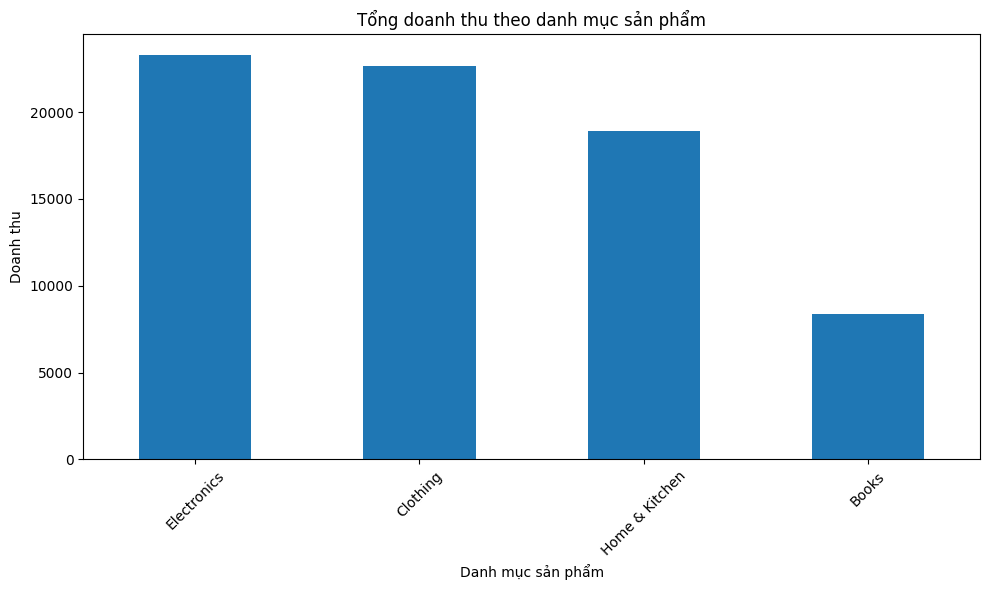

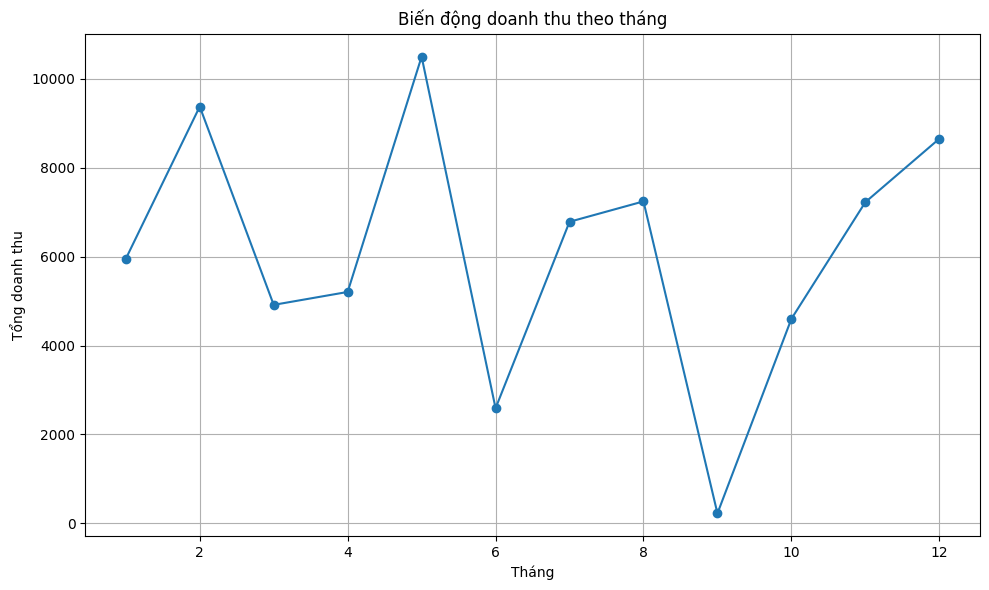

In [ ]:
category_revenue = (
    df.groupby("Product_Category")["Revenue"]
    .sum()
    .sort_values(ascending=False)
)

plt.figure(figsize=(10, 6))

category_revenue.plot(kind="bar")

plt.title("Tổng doanh thu theo danh mục sản phẩm")
plt.xlabel("Danh mục sản phẩm")
plt.ylabel("Doanh thu")

plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

# 2. Biểu đồ đường doanh thu theo tháng

monthly_revenue = (
    df.groupby("Month")["Revenue"]
    .sum()
)

plt.figure(figsize=(10, 6))

plt.plot(
    monthly_revenue.index,
    monthly_revenue.values,
    marker="o"
)

plt.title("Biến động doanh thu theo tháng")
plt.xlabel("Tháng")
plt.ylabel("Tổng doanh thu")

plt.grid(True)

plt.tight_layout()
plt.show()